# Task 1: Shooting Efficiency — Finishing Performance Relative to Expected Goals (xG)

**Analytic Question:** Among World Cup 2026 players who registered a non-zero Expected Goals (xG) value, is the average Goals-to-xG ratio significantly different from 1.0? As a secondary investigation, does this ratio differ between forwards and midfielders?

**Data source:** FIFA official World Cup 2026 statistics hub, Attacking category. Data was copied manually from the website's table (using the browser's copy function) and parsed in Python, since this was more reliable than browser automation for this dataset.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Data Wrangling — Manual Data Acquisition

The Attacking stats table was manually selected and copied from FIFA's website, then parsed in Python into a structured table. Unlike scraping the raw page HTML, manually copied text comes out with each field already separated onto its own line, so no additional text-splitting was required.

In [2]:
df = pd.read_csv("fifa_attacking_stats_real.csv")
print("Loaded! Shape:", df.shape)
df.head(10)

Loaded! Shape: (100, 14)


,Rank,player_name,nation,position,Assists,Attempts On Target,Attempts At Goal,Attempts At Goal Conv. Rate (%),Attempts Inside the Penalty Area,Attempts Outside the Penalty Area,Headed Attempts at Goal,xG,xG Efficiency,Corners
0,1,Michael Olise,FRA,FW,7,5,20,0.0,10,10,0,2.34,0x,25
1,2,Martin Odegaard,NOR,MF,4,3,9,0.0,5,4,0,0.72,0x,12
2,2,Kylian Mbappe,FRA,FW,4,23,41,24.0,27,14,0,6.54,1.53x,5
3,2,Brahim Diaz,MAR,FW,4,1,6,0.0,4,2,0,0.31,0x,1
4,2,Bruno Guimaraes,BRA,MF,4,2,8,0.0,5,3,1,1.02,0x,8
5,2,Lionel Messi,ARG,FW,4,19,35,23.0,16,19,0,6.18,1.29x,38
6,7,Roberto Alvarado,MEX,FW,3,0,5,0.0,2,3,0,0.28,0x,14
7,7,Anthony Gordon,ENG,FW,3,4,6,17.0,6,0,2,0.70,1.43x,0
8,7,Florian Wirtz,GER,MF,3,1,10,0.0,5,5,0,0.97,0x,5
9,7,Andreas Schjelderup,NOR,MF,3,2,3,33.0,3,0,0,0.20,5.12x,0


## 2. Approach A: Shot-Conversion Rate

### Applying Exclusions

Players with 0 attempts at goal are excluded, since a conversion rate cannot be meaningfully calculated without at least one shot attempt.

In [3]:
before = len(df)
df_clean = df[df['Attempts At Goal'] > 0].copy()
print(f"Excluded {before - len(df_clean)} players with 0 attempts at goal")
print("Population size:", len(df_clean))
print("Population mean conversion rate:", round(df_clean['Attempts At Goal Conv. Rate (%)'].mean(), 3))

Excluded 11 players with 0 attempts at goal
Population size: 89
Population mean conversion rate: 12.843


### Sampling

A simple random sample of n = 30 is drawn from the population using a fixed random seed for reproducibility.

In [4]:
n = 30
sample = df_clean.sample(n=n, random_state=42)
print(f"Sample size: {n}")
sample[['player_name','position','Attempts At Goal','Attempts At Goal Conv. Rate (%)']].head(10)

Sample size: 30


,player_name,position,Attempts At Goal,Attempts At Goal Conv. Rate (%)
45,Nicolas Jackson,FW,7,0.0
54,Yan Diomande,FW,4,0.0
30,Julio Enciso,FW,8,13.0
12,Chris Wood,FW,5,0.0
50,Haissem Hassan,FW,1,0.0
0,Michael Olise,FW,20,0.0
68,Ritsu Doan,MF,1,0.0
18,Nicolas Raskin,MF,2,0.0
10,Bukayo Saka,FW,13,23.0
22,Leandro Trossard,FW,17,12.0


### Descriptive Statistics, Confidence Interval, and One-Sample t-Test

- **Descriptive statistics** summarise the sample's shot-conversion rate.
- A **95% confidence interval** estimates the likely range for the true population mean.
- A **one-sample t-test** compares the sample mean against a 15% benchmark.

**H₀:** population mean conversion rate = 15%    **H₁:** population mean conversion rate ≠ 15%

In [5]:
rate = sample['Attempts At Goal Conv. Rate (%)']

print("=== DESCRIPTIVE STATISTICS ===")
print(rate.describe())
print("Skewness:", round(rate.skew(), 3))

print("\n=== 95% CONFIDENCE INTERVAL ===")
mean = rate.mean()
sem = stats.sem(rate)
ci = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=sem)
print(f"Sample mean: {mean:.3f}%   95% CI: ({ci[0]:.3f}%, {ci[1]:.3f}%)")

print("\n=== ONE-SAMPLE T-TEST (vs 15%) ===")
t_stat, p_value = stats.ttest_1samp(rate, popmean=15.0)
print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

=== DESCRIPTIVE STATISTICS ===
count     30.000000
mean      12.100000
std       20.920787
min        0.000000
25%        0.000000
50%        0.000000
75%       21.500000
max      100.000000
Name: Attempts At Goal Conv. Rate (%), dtype: float64
Skewness: 2.793

=== 95% CONFIDENCE INTERVAL ===
Sample mean: 12.100%   95% CI: (4.288%, 19.912%)

=== ONE-SAMPLE T-TEST (vs 15%) ===
t = -0.7592, p = 0.4538
Decision: Fail to reject H0


### Two-Sample t-Test — Forwards vs. Midfielders

As an additional analysis, the sample is split by position to compare conversion rates between forwards and midfielders, two independent groups.

**H₀:** mean conversion rate (FW) = mean conversion rate (MF)    **H₁:** mean conversion rate (FW) ≠ mean conversion rate (MF)

In [6]:
fw_pop = df_clean[df_clean['position']=='FW']['Attempts At Goal Conv. Rate (%)']
mf_pop = df_clean[df_clean['position']=='MF']['Attempts At Goal Conv. Rate (%)']
print("FW population:", len(fw_pop), " MF population:", len(mf_pop))

n_fw, n_mf = min(20, len(fw_pop)), min(15, len(mf_pop))
fw_sample = fw_pop.sample(n=n_fw, random_state=42)
mf_sample = mf_pop.sample(n=n_mf, random_state=42)
print(f"FW sample (n={n_fw}) mean: {fw_sample.mean():.3f}%")
print(f"MF sample (n={n_mf}) mean: {mf_sample.mean():.3f}%")

levene_stat, levene_p = stats.levene(fw_sample, mf_sample)
equal_var = levene_p > 0.05
print(f"Levene p={levene_p:.4f} -> equal_var={equal_var}")

t_stat2, p_value2 = stats.ttest_ind(fw_sample, mf_sample, equal_var=equal_var)
print(f"t = {t_stat2:.4f}, p = {p_value2:.4f}")
print("Decision:", "Reject H0" if p_value2 < 0.05 else "Fail to reject H0")

FW population: 39  MF population: 32
FW sample (n=20) mean: 17.850%
MF sample (n=15) mean: 17.200%
Levene p=0.7120 -> equal_var=True
t = 0.0748, p = 0.9408
Decision: Fail to reject H0


---

# Approach B (More Rigorous): Goals-to-Expected-Goals Ratio

Raw conversion percentage treats every shot equally, regardless of difficulty. This section repeats the same analysis using a more analytically valid variable: **Goals ÷ Expected Goals (xG)**, which accounts for shot quality.

## 3. Building the Analysis Variable and Applying Exclusions

The "xG Efficiency" field is published as text (e.g. "1.53x"), so it is cleaned into a numeric Goals-to-xG ratio. Players with an xG value of 0 are excluded, since the ratio is undefined without any registered shot quality.

In [7]:
df['goal_xg_ratio'] = df['xG Efficiency'].str.replace('x', '', regex=False).astype(float)
df_clean_xg = df[df['xG'] > 0].copy()
print("Population size:", len(df_clean_xg))
print("Population mean Goals/xG ratio:", round(df_clean_xg['goal_xg_ratio'].mean(), 3))

Population size: 88
Population mean Goals/xG ratio: 1.329


### Sampling

A simple random sample of n = 30 is drawn from this population using a fixed random seed.

In [8]:
sample_xg = df_clean_xg.sample(n=30, random_state=42)
print("Sample size:", len(sample_xg))
sample_xg[['player_name','position','xG','goal_xg_ratio']].head(10)

Sample size: 30


,player_name,position,xG,goal_xg_ratio
84,Baris Alper Yilmaz,FW,0.06,16.87
0,Michael Olise,FW,2.34,0.00
26,Ousmane Dembele,FW,2.10,2.86
22,Leandro Trossard,FW,1.67,1.20
12,Chris Wood,FW,0.47,0.00
74,Kaishu Sano,MF,0.09,11.52
10,Bukayo Saka,FW,1.72,1.74
18,Nicolas Raskin,MF,0.13,0.00
4,Bruno Guimaraes,MF,1.02,0.00
75,Lee Kangin,MF,0.15,0.00


### Descriptive Statistics, Confidence Interval, and One-Sample t-Test

**H₀:** population mean Goals/xG ratio = 1.0    **H₁:** population mean Goals/xG ratio ≠ 1.0

In [9]:
ratio = sample_xg['goal_xg_ratio']

print("=== DESCRIPTIVE STATISTICS ===")
print(ratio.describe())
print("Skewness:", round(ratio.skew(), 3))

print("\n=== 95% CONFIDENCE INTERVAL ===")
mean_xg = ratio.mean()
sem_xg = stats.sem(ratio)
ci_xg = stats.t.interval(confidence=0.95, df=29, loc=mean_xg, scale=sem_xg)
print(f"Sample mean: {mean_xg:.3f}   95% CI: ({ci_xg[0]:.3f}, {ci_xg[1]:.3f})")

print("\n=== ONE-SAMPLE T-TEST (vs 1.0) ===")
t_stat_xg, p_value_xg = stats.ttest_1samp(ratio, popmean=1.0)
print(f"t = {t_stat_xg:.4f}, p = {p_value_xg:.4f}")
print("Decision:", "Reject H0" if p_value_xg < 0.05 else "Fail to reject H0")

=== DESCRIPTIVE STATISTICS ===
count    30.000000
mean      2.171333
std       3.727846
min       0.000000
25%       0.000000
50%       1.045000
75%       2.660000
max      16.870000
Name: goal_xg_ratio, dtype: float64
Skewness: 2.799

=== 95% CONFIDENCE INTERVAL ===
Sample mean: 2.171   95% CI: (0.779, 3.563)

=== ONE-SAMPLE T-TEST (vs 1.0) ===
t = 1.7210, p = 0.0959
Decision: Fail to reject H0


### Two-Sample t-Test — Forwards vs. Midfielders

**H₀:** mean ratio (FW) = mean ratio (MF)    **H₁:** mean ratio (FW) ≠ mean ratio (MF)

In [10]:
fw_pop_xg = df_clean_xg[df_clean_xg['position']=='FW']['goal_xg_ratio']
mf_pop_xg = df_clean_xg[df_clean_xg['position']=='MF']['goal_xg_ratio']
print("FW population:", len(fw_pop_xg), " MF population:", len(mf_pop_xg))

n_fw2, n_mf2 = min(20, len(fw_pop_xg)), min(15, len(mf_pop_xg))
fw_sample_xg = fw_pop_xg.sample(n=n_fw2, random_state=42)
mf_sample_xg = mf_pop_xg.sample(n=n_mf2, random_state=42)
print(f"FW sample (n={n_fw2}) mean: {fw_sample_xg.mean():.3f}")
print(f"MF sample (n={n_mf2}) mean: {mf_sample_xg.mean():.3f}")

levene_stat2, levene_p2 = stats.levene(fw_sample_xg, mf_sample_xg)
equal_var2 = levene_p2 > 0.05
print(f"Levene p={levene_p2:.4f} -> equal_var={equal_var2}")

t_stat3, p_value3 = stats.ttest_ind(fw_sample_xg, mf_sample_xg, equal_var=equal_var2)
print(f"t = {t_stat3:.4f}, p = {p_value3:.4f}")
print("Decision:", "Reject H0" if p_value3 < 0.05 else "Fail to reject H0")

FW population: 39  MF population: 31
FW sample (n=20) mean: 1.804
MF sample (n=15) mean: 2.137
Levene p=0.5972 -> equal_var=True
t = -0.2795, p = 0.7816
Decision: Fail to reject H0


## 4. Visualising the Distribution

A histogram of the sample's Goals/xG ratio, with the xG-neutral benchmark (1.0) and sample mean marked.

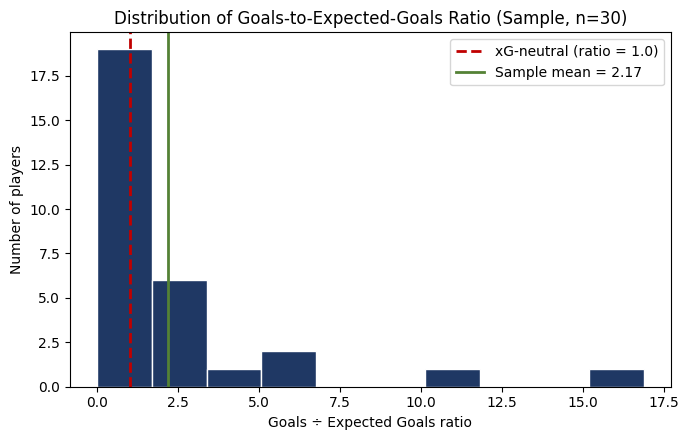

In [11]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(sample_xg['goal_xg_ratio'], bins=10, color='#1F3864', edgecolor='white')
ax.axvline(1.0, color='#C00000', linestyle='--', linewidth=2, label='xG-neutral (ratio = 1.0)')
ax.axvline(sample_xg['goal_xg_ratio'].mean(), color='#548235', linestyle='-', linewidth=2,
           label=f"Sample mean = {sample_xg['goal_xg_ratio'].mean():.2f}")
ax.set_xlabel('Goals ÷ Expected Goals ratio')
ax.set_ylabel('Number of players')
ax.set_title('Distribution of Goals-to-Expected-Goals Ratio (Sample, n=30)')
ax.legend()
plt.tight_layout()
plt.savefig('xg_ratio_distribution.png', dpi=150)
plt.show()

## Conclusion

**Approach A (Conversion Rate):**
- One-sample t-test vs 15%: t = -0.759, p = 0.454 → fail to reject H₀
- Two-sample t-test (FW vs MF): t = 0.075, p = 0.941 → fail to reject H₀

**Approach B (Goals/xG Ratio):**
- One-sample t-test vs 1.0: t = 1.721, p = 0.096 → fail to reject H₀
- Two-sample t-test (FW vs MF): t = -0.280, p = 0.782 → fail to reject H₀

Across both approaches and both tests, no statistically significant deviation was found — players finished roughly in line with expectations, both against fixed benchmarks and when compared by position. The sample distribution is strongly right-skewed in both approaches: most players convert few or none of their chances, while a small number of standout finishers substantially outperform expectation.

**Limitation:** the population reflects FIFA's published Attacking leaderboard (players with ≥1 assist), not every player in the tournament who took a shot.